### 引言

在房价预测代码中，模型的输出 $y$ 是一个**连续的数值**。
*   **公式**：$y = w^Tx + b$
*   **场景**：预测房价、气温、销量。

现在，假设我们要做一个**手写数字识别**（MNIST）任务。
*   **输入**：一张图片。
*   **输出**：这张图片是 0 到 9 中的哪一个数字？

如果我们直接用线性回归：
*   模型可能会输出 `3.5`。这代表什么？是数字 3 还是 4？
*   模型可能会输出 `10`。这代表数字 10 吗？可是我们只有 0-9 这 10 个类别。

**结论**：我们需要一种机制，把线性回归输出的“任意数值”，转换成**“属于每个类别的概率”**（即 0 到 1 之间，且所有类别概率之和为 1）。

这就是 **Softmax** 的作用。

### softmax结构

从神经网络的角度看，这两个模型的结构非常相似，只是**输出层**变了。

#### 1. 线性回归结构
*   **输入**：特征向量 $x$（比如面积、房龄）。
*   **运算**：$y = w^Tx + b$。
*   **输出**：一个标量数值 $y$。
*   **PyTorch 代码**：`nn.Linear(in_features=2, out_features=1)`

#### 2. Softmax 回归结构
*   **输入**：特征向量 $x$（比如图片的 784 个像素点）。
*   **运算（线性层）**：
    *   这次我们不再只输出 1 个数，而是输出 **$k$ 个数**（$k$ 是类别数量，比如 10 个数字，k就等于10）。
    *   我们会得到一组原始分数（Logits）：$[z_1, z_2, ..., z_{10}]$。
    *   这本质上还是线性回归：$z_i = w_i^Tx + b_i$。
*   **运算（Softmax 层）**：
    *   把这组分数 $[z_1, ..., z_{10}]$ 扔进 Softmax 函数。
    *   **Softmax 函数公式**：
        $$ \hat{y}_i = \frac{\exp(z_i)}{\sum_{j=1}^{k} \exp(z_j)} $$
    *   **作用**：
        1.  **$\exp(z_i)$**：把所有负数变成正数（指数函数性质）。
        2.  **分母求和**：把所有结果归一化，使得所有 $\hat{y}$ 加起来等于 1。
*   **输出**：一个概率分布向量。例如 `[0.01, 0.01, 0.9, 0.01, ...]`，表示有 90% 的概率是数字 2。

**结构对比表**：

| 特性 | 线性回归 | Softmax 回归 |
| :--- | :--- | :--- |
| **任务** | 预测数值 (回归) | 预测类别 (多分类) |
| **输出层维度** | 1 | 类别数量 $k$ (如 10) |
| **激活函数** | 无 (恒等映射) | **Softmax** |
| **输出含义** | 具体数值 (如 150万) | 概率分布 (如 90%是猫) |

---

### softmax的损失函数

线性回归用 **均方误差 (MSE)**，但在分类任务中，MSE 不好用（因为它是非凸的，很难优化）。我们需要一个新的尺子来衡量“预测概率”和“真实标签”之间的距离。

#### 交叉熵损失
这是 Softmax 回归的黄金搭档。

*   **真实标签**：通常用 **One-hot 编码** 表示。
    *   如果是数字 "2"，标签是 `[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]`。
*   **预测结果**：`[0.1, 0.1, 0.6, 0.05, ...]` (预测是 2 的概率是 0.6)。
*   **目标**：让预测概率中，“正确类别”的概率尽可能接近 1。

**交叉熵公式**：
$$ L = - \sum_{i=1}^{k} y_i \log(\hat{y}_i) $$
由于真实标签 $y$ 只有一个位置是 1，其余是 0，公式简化为：
$$ L = - \log(\hat{y}_{\text{正确类别}}) $$

**直观理解**：
*   如果模型预测正确类别的概率很高（0.9），$-\log(0.9)$ 很小（损失小）。
*   如果模型预测正确类别的概率很低（0.1），$-\log(0.1)$ 很大（损失大，狠狠惩罚）。

---

### 代码层面的对比

让我们看看 PyTorch 代码是如何从线性回归“变身”的。

#### 1. 线性回归代码
```python
# 输入: 2个特征, 输出: 1个数值
model = nn.Linear(2, 1) 
# 损失函数: 均方误差
criterion = nn.MSELoss() 
```

#### 2. Softmax 回归代码
```python
# 假设输入是 784 维像素，输出是 10 个类别
# 注意：这里不需要显式写 Softmax 层！
# PyTorch 的 CrossEntropyLoss 内部已经包含了 Softmax
model = nn.Linear(784, 10) 

# 损失函数: 交叉熵 (它接受原始分数 logits，内部自动做 softmax)
criterion = nn.CrossEntropyLoss() 
```

**关键点**：
在 PyTorch 中，我们通常**不**把 `nn.Softmax()` 加在模型里。我们让模型输出原始分数（Logits），直接扔给 `nn.CrossEntropyLoss()`，这样计算效率更高，数值更稳定。



### 代码实现

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

import os
# 设置 Hugging Face 的镜像地址（MNIST 现在托管在 HF 上）
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

In [2]:
# ==========================================
# 1. 数据准备
# ==========================================
# MNIST 图片是 28x28 的灰度图
# transforms.ToTensor() 会把图片变成张量，并把像素值从 [0, 255] 归一化到 [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    # 标准化：(x - 0.1307) / 0.3081，这是 MNIST 的标准配置，有助于模型收敛
    transforms.Normalize((0.1307,), (0.3081,))
])

# 下载并加载训练集
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

# 加载测试集
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

100.0%
100.0%
100.0%
100.0%


In [9]:
# ==========================================
# 2. 定义模型 (Softmax 回归)
# ==========================================
class SoftmaxRegression(nn.Module):
    def __init__(self):
        super(SoftmaxRegression, self).__init__()
        # 输入维度：28 * 28 = 784 (把图片拉平成向量)
        # 输出维度：10 (0-9 十个数字类别)
        self.linear = nn.Linear(784, 10)
        
    def forward(self, x):
        # x.shape: [batch_size, 1, 28, 28]
        # 第一步：展平图片。把 [64, 1, 28, 28] 变成 [64, 784]
        # -1：这一维的大小我不确定，请你根据总数据量自动帮我算出来
        x = x.view(-1, 784)
        # 第二步：线性变换。输出原始分数 (Logits)
        # 注意：这里不需要加 Softmax！因为 CrossEntropyLoss 内部会自动处理
        out = self.linear(x)
        return out

model = SoftmaxRegression()

In [12]:
# ==========================================
# 3. 定义损失函数与优化器
# ==========================================
# 关键点：使用交叉熵损失函数
# nn.CrossEntropyLoss() = Softmax + NLLLoss (负对数似然)
# 它会自动帮我们计算 Softmax 并求损失，所以我们模型里不用写 Softmax 层
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1) # 学习率设大一点，因为是简单模型

In [13]:
# ==========================================
# 4. 训练循环
# ==========================================
num_epochs = 5
print("开始训练...")
for epoch in range(num_epochs):
    total_loss = 0
    for images, labels in train_loader:
        # 1. 前向传播
        outputs = model(images)
        # 2. 计算损失
        loss = criterion(outputs, labels)
        
        # 3. 反向传播与优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    #if (epoch + 1) % 5 == 0:
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}')

开始训练...
Epoch [1/5], Loss: 0.3674
Epoch [2/5], Loss: 0.3148
Epoch [3/5], Loss: 0.3032
Epoch [4/5], Loss: 0.2976
Epoch [5/5], Loss: 0.2938


In [16]:
# ==========================================
# 5. 评估模型
# ==========================================
print("\n开始测试...")
correct = 0
total = 0
with torch.no_grad(): # 测试时不需要计算梯度
    for images, labels in test_loader:
        outputs = model(images)
        # 找到概率最大的那个类别的索引
        # outputs.data.max(1) 返回 (最大值, 最大值的索引)
        _, predicted = torch.max(outputs.data, 1)
        # print(predicted)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        # print((predicted == labels).sum())
print(f'测试集准确率: {100 * correct / total:.2f}%')


开始测试...
测试集准确率: 91.33%


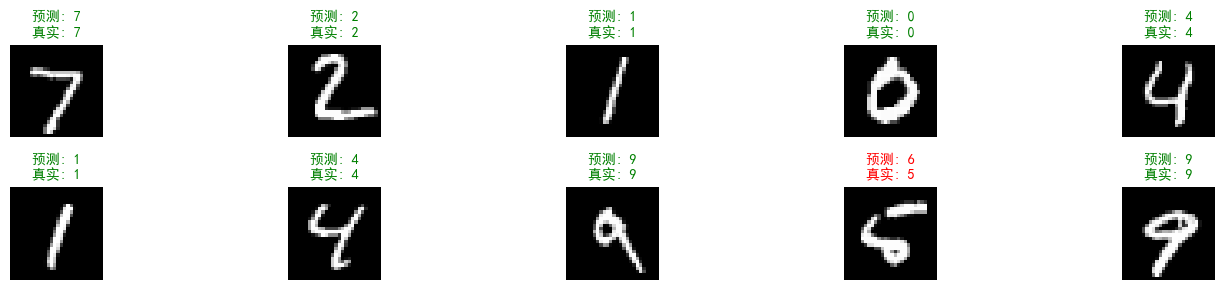

In [23]:
# ==========================================
# 6. 可视化预测结果
# ==========================================
plt.rcParams['font.sans-serif'] = ['SimHei']
# 随便拿一批测试数据看看
iterator = iter(test_loader) # 迭代器
images, labels = next(iterator)
outputs = model(images)
_, predicted = torch.max(outputs.data, 1)

plt.figure(figsize=(15, 3))
for i in range(10): # 显示前10张图
    plt.subplot(2, 5, i+1)
    # 反归一化用于显示 (img * std + mean)
    img = images[i] * 0.3081 + 0.1307 
    plt.imshow(img.squeeze().numpy(), cmap='gray')
    
    # 预测对了显示绿色，错了显示红色
    color = 'green' if predicted[i] == labels[i] else 'red'
    plt.title(f"预测: {predicted[i].item()}\n真实: {labels[i].item()}", color=color, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()